
# 🧠 Keras Transfer Learning - Classificació

---
![image](https://miro.medium.com/v2/resize:fit:640/format:webp/0*CCO8qrBn-J14H62o.png)


## 🎯 Objectius

* Aquest notebook pretén mostrar un exemple de Transfer Learning amb Keras
* La idea és utilitzar una xarxa preentrenada que és capaç de classificar els 10 dígits del dataset MINST per tal de que sàpiga classificar si el número és parell o senar.


## 📦 Datasets

En aquest notebook utlitzarem el conjunt de dades MNIST. Conjunt de 70.00 imatges petites de dígits escrits a mà.
Cada mostra està etiquetada amb el dígitt qur el representa (0-9).

Aquest cojunt de dades és un dels més utilitzats i se'l anomena el "Hola món!" dle la classificació d'imatges en Machine Lerning.
Cada vegada que algú troba un nou algorisme de classificació, sent curioristat com es comportarà amb el dataset MINST.

* Tenim 70.000 imatges
* Cada imatge té 784 caracrerístiques perquè són imatge de 28x28 pixels.
* Cada característica representa la intensitat d'un ixel, des de 0(blanc) a 255(negre)Al conjunt de dades MNIST, cada mostra és una imatge d’un dígit escrit a mà. Cada mostra inclou valors de píxels en escala de grisos de 28×28 com a característiques, i una etiqueta de classe categòrica entre 0 i 9. Per a més detalls, consulteu la pàgina del Dr. Yann LeCun (http://yann.lecun.com/exdb/mnist/
). El conjunt de dades s’ha importat utilitzant el paquet sklearn.dataset.

In [30]:
#!pip install tensorflow


## 🟦 0. Import Classes

In [31]:
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
import os
import time
import pandas as pd

# Definició d'una funció per mostrar un dígit mitjançant mmatplotlib.
def show_digit(x_vec, label, cmap="binary"):
    x_mat = x_vec.reshape(28, 28)
    plt.imshow(x_mat,cmap)
    plt.title('L\'etiqueta del dígit és: ' + str(label))
    plt.show()


## 🟦 1. Load Dataset

In [32]:
df = tf.keras.datasets.mnist

(X_train,y_train),(X_test, y_test) = df.load_data()

print(f'Tenim un total de {X_train.shape[0]} imatges de Train')
print(f'Tenim un total de {X_test.shape[0]} imatges de Test')
print('Shape de les característiques:', X_train.shape)

Tenim un total de 60000 imatges de Train
Tenim un total de 10000 imatges de Test
Shape de les característiques: (60000, 28, 28)


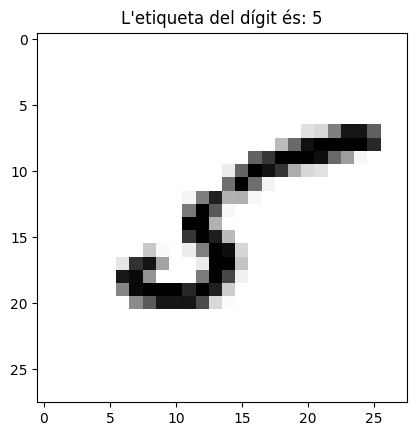

In [33]:
show_digit(X_train[11], y_train[11],"binary")

## 🟦 2. Model

### Definició

In [34]:
fc_model = tf.keras.Sequential()
fc_model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
fc_model.add(tf.keras.layers.Dense(128, activation='relu'))
fc_model.add(tf.keras.layers.Dense(64, activation = 'relu'))
fc_model.add(tf.keras.layers.Dense(10))
fc_model.add(tf.keras.layers.Softmax())

fc_model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

fc_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenament

In [35]:
fc_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7939 - loss: 5.0815 - val_accuracy: 0.9032 - val_loss: 0.4090
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9100 - loss: 0.3659 - val_accuracy: 0.9320 - val_loss: 0.2654
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9343 - loss: 0.2456 - val_accuracy: 0.9371 - val_loss: 0.2318
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9451 - loss: 0.2004 - val_accuracy: 0.9429 - val_loss: 0.2164
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9566 - loss: 0.1536 - val_accuracy: 0.9539 - val_loss: 0.1851
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9614 - loss: 0.1379 - val_accuracy: 0.9475 - val_loss: 0.1972
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9662 - loss: 0.1200 - val_accuracy: 0.9555 - val_loss: 0.1763
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9682 - loss: 0.1074 - 

In [36]:
#fc_model.save('fc_model_minst_preentrenat.h5') #Foramt legacy
fc_model.save('fc_model_minst_preentrenat.keras')

## 🟦 3. Transfer Learning

Carreguem el model preentrenat amb el dataset MINST

In [37]:
# Carreguem el model que tenim guardat per realitzar una classifiació binària
fc_model_pt = tf.keras.models.load_model('fc_model_minst_preentrenat.keras')

fc_model_pt.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

Iterem per cada capa del model per verificar si és entrenable o no.

In [38]:
for layer in fc_model_pt.layers:
    print(f"{layer.name} - {layer.trainable}")

flatten_1 - True
dense_4 - True
dense_5 - True
dense_6 - True
softmax_1 - True


Congelem totes les capes perquè no es puguin reentrenat.

In [39]:
# Congelem l'entrenament de totes les capes menys la última
for layer in fc_model_pt.layers[:-1]:
    layer.trainable = False

# Comprovem que la propietat trainable ha canviat a false.
for layer in fc_model_pt.layers:
    print(f"{layer.name} - {layer.trainable}")

flatten_1 - False
dense_4 - False
dense_5 - False
dense_6 - False
softmax_1 - True


### Definim el nou model

Traiem la última capa softmax perquè aquesta tenia 10 neurones per classificar els 10 dígits. Per tant ens volem quedar amb totes les altres excepte aquesta

In [40]:
fc_model_pt_layers = fc_model_pt.layers[:-1] # Traiem la última capa
#Construim el nou model per distingir entre 2 classes (senar/parell)
fc_model_sp = tf.keras.models.Sequential(fc_model_pt_layers)

# Podem afegir una última capa de 2 neurones amb una SoftMax
#fc_model_sp.add(
#        tf.keras.layers.Dense(2,activation='softmax')
#)
#fc_model.add(tf.keras.layers.Softmax())

#Podem afegir una funció d'activació Sigmoid
fc_model_sp.add(tf.keras.layers.Dense(1,activation='sigmoid'))


fc_model_sp.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 109,386 (427.29 KB)

In [41]:
# Canviem el tf.keras.losses.SparseCategoricalCrossentropy() per binary_crossentropy
fc_model_sp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Preparem el nou dataset perquè tinguem l'etiqueta de senar/parell

In [42]:
def updated_even_odd_labels(labels):
    for idx, label in enumerate(labels):
        labels[idx] = np.where(label % 2 == 0 , 1, 0)
    return labels

y_train_sp, y_test_sp = updated_even_odd_labels([y_train, y_test])

In [43]:
y_train_sp[1]

np.int64(1)

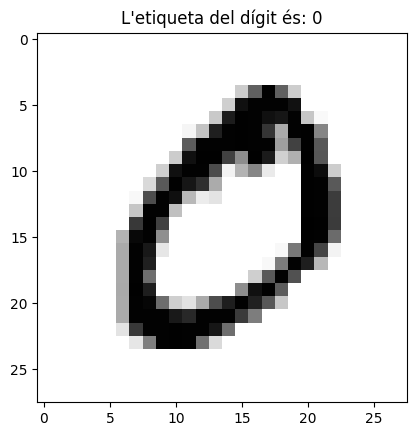

In [44]:
show_digit(X_train[1], y_train[1],"binary")

In [45]:
fc_model_sp.fit(
    X_train, y_train_sp,
    validation_split=0.2,
    epochs=10
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5489 - loss: 5.8043 - val_accuracy: 0.9494 - val_loss: 0.1441
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9644 - loss: 0.1098 - val_accuracy: 0.9688 - val_loss: 0.0998
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9757 - loss: 0.0784 - val_accuracy: 0.9719 - val_loss: 0.0943
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9772 - loss: 0.0706 - val_accuracy: 0.9726 - val_loss: 0.0931
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9773 - loss: 0.0697 - val_accuracy: 0.9721 - val_loss: 0.0916
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9768 - loss: 0.0677 - val_accuracy: 0.9732 - val_loss: 0.0910
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9776 - loss: 0.0666 - val_accuracy: 0.9732 - val_loss: 0.0913
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9796 - loss: 0.0637 - 

## 🟦 4. Avaluació

Veiem que realitzant el Transfer Learning aconseguim unes mètriques molt bones de 0.95

In [46]:
_ = fc_model_sp.evaluate(X_test, y_test_sp, verbose = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9708 - loss: 0.0801


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


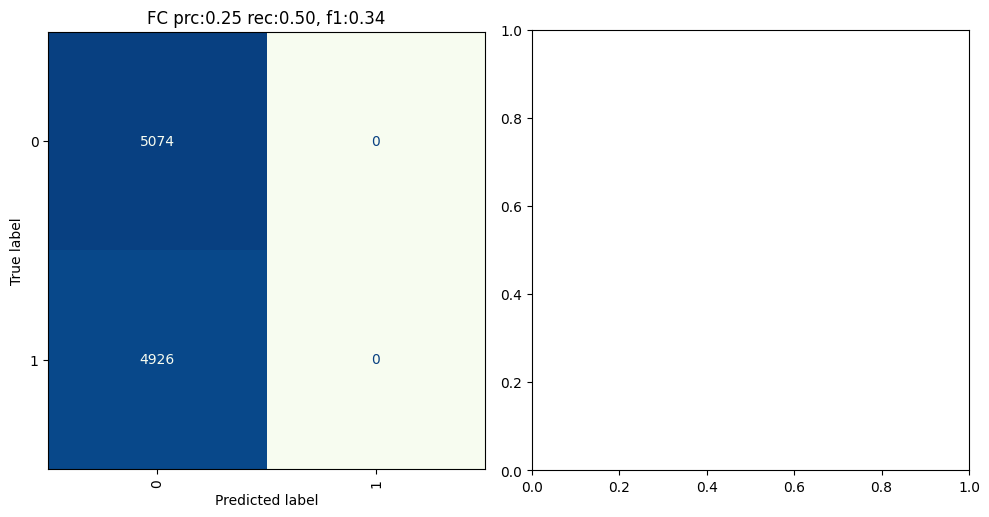

In [47]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,confusion_matrix, accuracy_score, precision_score,
    recall_score, precision_recall_fscore_support, f1_score, roc_curve, auc, precision_recall_curve
)

fc_proba = fc_model_sp.predict(X_test)
fc_preds = np.argmax(fc_proba, axis=1)

models = [
    ("FC", fc_preds)
]

print(len(models))
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
for axi, (model_name, preds) in zip(axs.flatten(), models):
    prc, rec, f1, _ = precision_recall_fscore_support(y_test_sp, preds, average = 'macro')
    axi.set_title(f"{model_name} prc:{prc:.2f} rec:{rec:.2f}, f1:{f1:.2f}");
    ConfusionMatrixDisplay.from_predictions(
        y_test_sp,
        preds,
        normalize = None,
        values_format = 'd',
        display_labels = [0,1],
        ax = axi,
        xticks_rotation = 90,
        cmap = 'GnBu',
        colorbar = False
    )
plt.tight_layout();